# Friedkin--Johnsen structured-topology discovery

This notebook searches for a **mechanism-driven structured environment** in
which uniform intervention is inefficient but graph-aware targeted intervention
has a genuine opportunity to do better.

It is deliberately split into two stages.

### Stage A — oracle topology screen

A family of directed, two-hub broadcaster networks is screened using only:

- no control;
- uniform control;
- true-graph centrality control.

Candidates are ranked by the paired advantage of true-graph control over
uniform control.  **The learned controller is not used to choose the topology.**

### Stage B — learned-controller validation

The top oracle-promising candidates are frozen.  The actual online nonlinear
identifier/controller is then run with repeated training seeds.  This tells us
whether the current single-shot pipeline can recover the exploitable structure.


The FJ search looks for **influential low-opinion broadcasters**.  In the
repository convention, `A[i,j]` means agent `j` influences agent `i`, so a
broadcaster is represented by a large **column**, not a large row.

Peripheral agents therefore assign a large fraction of their incoming social
weight to one or both hubs.  The hubs start below the peripheral agents.  A
uniform campaign spends most of its budget directly on leaves, whereas a
targeted campaign can move the broadcasters that subsequently affect many
agents.

The calibrated FJ susceptibility is kept fixed at `lambda = 0.98`, and each
candidate uses `prejudice = x0`, matching the parameter-screen convention.


The main-paper settings are retained: 15 nodes, 20 campaigns, campaign 0
passive, total controlled budget 6, per-node cap 0.2, no explicit random
exploration, and `lambda_mix = 0.70`.

The notebook caches every learned-validation run.  After validation it plots all
15 individual node trajectories for the best candidate.

In [1]:
from __future__ import annotations

import hashlib
import inspect
import json
import os
import random
import subprocess
import sys
import time
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

pd.set_option("display.max_columns", 220)
pd.set_option("display.width", 260)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "opinion_dynamics").exists():
            return candidate
    raise RuntimeError(
        "Could not find repository root containing opinion_dynamics/."
    )


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rl_envs_forge.envs.network_graph.network_graph import NetworkGraph
from rl_envs_forge.envs.network_graph.graph_utils import (
    compute_eigenvector_centrality,
    compute_laplacian,
)
from opinion_dynamics.baseline import centrality_based_continuous_control
import opinion_dynamics.experiments.online_single_shot as online_single_shot_module

run_single_shot_online_identification = (
    online_single_shot_module.run_single_shot_online_identification
)

try:
    GIT_COMMIT = subprocess.run(
        ["git", "rev-parse", "--short", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except Exception:
    GIT_COMMIT = "unknown"

print("Repository root:", REPO_ROOT)
print("Git commit:", GIT_COMMIT)
print(
    "online_single_shot:",
    inspect.getsourcefile(online_single_shot_module),
)
print("NetworkGraph:", inspect.getsourcefile(NetworkGraph))

C:\Users\Chainsword\AppData\Local\Temp\ipykernel_67344\225419917.py:17: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Repository root: d:\Work\repos\RL\unknown_graph_networks
Git commit: 6c7a1bf
online_single_shot: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\online_single_shot.py
NetworkGraph: c:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\rl_envs_forge\envs\network_graph\network_graph.py


## Configuration

In [2]:
STUDY_NAME = "fj_structured_topology_discovery"
PIPELINE_VERSION = "2026-08-15-v1"

# Worker mode is optional.  Example:
#   set FJ_DISCOVERY_SHARD_ID=0
# followed by nbconvert execution.
SHARD_ENV = "FJ_DISCOVERY_SHARD_ID"
THREAD_ENV = "FJ_DISCOVERY_TORCH_THREADS"
NUM_SHARDS = 3

_shard_value = os.environ.get(SHARD_ENV)
WORKER_MODE = _shard_value is not None
SHARD_ID = int(_shard_value) if WORKER_MODE else None
if WORKER_MODE and SHARD_ID not in range(NUM_SHARDS):
    raise ValueError(f"{SHARD_ENV} must be 0, 1, or 2")

TORCH_THREADS = int(os.environ.get(THREAD_ENV, "3"))
torch.set_num_threads(max(1, TORCH_THREADS))
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

DEVICE = "cpu"

N = 15
HUBS = (0, 1)
LEAVES = tuple(range(2, N))
GROUP_A = tuple(range(2, 8))
GROUP_B = tuple(range(8, N))

TARGET = 1.0
NUM_CAMPAIGNS = 20
T_CAMPAIGN = 0.5
T_S = 0.1
MAX_U = 0.20
TOTAL_CONTROLLED_BUDGET = 6.0
B_CAMPAIGN = TOTAL_CONTROLLED_BUDGET / (NUM_CAMPAIGNS - 1)

LAMBDA_MIX = 0.70
EPSILON_SCHEDULE = [0.0] * NUM_CAMPAIGNS

FIT_LR = 1e-3
FIT_MAX_STEPS = 1_000
FIT_MAE_STOP = 5e-4
FIT_BATCH_SIZE = 256
FIT_CHECK_EVERY = 200
IDENTIFIER_KWARGS = {"hidden_dim": 16}

MODEL_KWARGS = {
    "fj_lambda": 0.98,
}

# Stage-A search grid.
TOPOLOGY_FAMILIES = [
    "dual_broadcast",
    "split_broadcast",
    "asymmetric_broadcast",
]
HUB_INFLUENCE_TOTALS = [0.55, 0.70, 0.85]
HUB_INITIAL_LEVELS = [0.16, 0.24, 0.32]
LEAF_INITIAL_LEVELS = [0.48, 0.58, 0.68]

# Stage B validates the best oracle-screen candidates.
TOP_K_CANDIDATES = 3
LEARNED_VALIDATION_SEEDS = [0, 1, 2, 3, 4]

RESULTS_ROOT = (
    REPO_ROOT
    / "opinion_dynamics"
    / "experiments"
    / "results"
)
RESULTS_DIR = (
    RESULTS_ROOT
    / f"experiment_2026_08_15_{STUDY_NAME}"
)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CACHE_ROOT = RESULTS_ROOT / "_trial_cache" / STUDY_NAME
CACHE_ROOT.mkdir(parents=True, exist_ok=True)

print("Mode:", "worker" if WORKER_MODE else "analysis")
if WORKER_MODE:
    print("Shard:", f"{SHARD_ID + 1}/{NUM_SHARDS}")
print("Campaign budget:", B_CAMPAIGN)
print("Uniform allocation per node:", B_CAMPAIGN / N)
print("Results:", RESULTS_DIR)
print("Cache:", CACHE_ROOT)

Mode: analysis
Campaign budget: 0.3157894736842105
Uniform allocation per node: 0.021052631578947368
Results: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\experiment_2026_08_15_fj_structured_topology_discovery
Cache: d:\Work\repos\RL\unknown_graph_networks\opinion_dynamics\experiments\results\_trial_cache\fj_structured_topology_discovery


## Preserve dynamics-specific parameters when the online runner clones the environment

In [3]:
def _copy_maybe(value: Any) -> Any:
    if isinstance(value, np.ndarray):
        return np.array(value, copy=True)
    if isinstance(value, list):
        return list(value)
    if isinstance(value, tuple):
        return tuple(value)
    return value


def patched_env_kwargs_from_env(
    env: Any,
    *,
    t_campaign: float | None = None,
    t_s: float | None = None,
) -> dict[str, Any]:
    kwargs = dict(
        connectivity_matrix=np.array(
            env.connectivity_matrix,
            copy=True,
        ),
        num_agents=int(env.num_agents),
        max_u=np.array(env.max_u, copy=True),
        desired_opinion=float(env.desired_opinion),
        t_campaign=float(
            env.t_campaign if t_campaign is None else t_campaign
        ),
        t_s=float(env.t_s if t_s is None else t_s),
        dynamics_model=str(env.dynamics_model),
        initial_opinions=np.array(
            getattr(env, "initial_opinions", env.opinions),
            copy=True,
        ),
        control_resistance=np.array(
            getattr(
                env,
                "control_resistance",
                np.zeros(env.num_agents),
            ),
            copy=True,
        ),
        max_steps=int(getattr(env, "max_steps", 10_000)),
        opinion_end_tolerance=float(
            getattr(env, "opinion_end_tolerance", 0.01)
        ),
        control_beta=float(
            getattr(env, "control_beta", 0.4)
        ),
        normalize_reward=bool(
            getattr(env, "normalize_reward", True)
        ),
        terminal_reward=float(
            getattr(env, "terminal_reward", 0.0)
        ),
        terminate_when_converged=bool(
            getattr(env, "terminate_when_converged", False)
        ),
        budget=float(getattr(env, "budget", 1000.0)),
        seed=(
            int(env.seed)
            if getattr(env, "seed", None) is not None
            else None
        ),
    )

    if str(env.dynamics_model).lower() == "friedkinjohnsen":
        kwargs["fj_lambda"] = _copy_maybe(env.fj_lambda)
        kwargs["fj_prejudice"] = _copy_maybe(env.fj_prejudice)

    if str(env.dynamics_model).lower() == "nonlinearinfluence":
        kwargs["nonlinear_beta"] = float(env.nonlinear_beta)

    return kwargs


def patched_make_env_from_template(
    env_template: Any,
    *,
    t_campaign: float | None = None,
    t_s: float | None = None,
) -> Any:
    return env_template.__class__(
        **patched_env_kwargs_from_env(
            env_template,
            t_campaign=t_campaign,
            t_s=t_s,
        )
    )


online_single_shot_module.env_kwargs_from_env = (
    patched_env_kwargs_from_env
)
online_single_shot_module.make_env_from_template = (
    patched_make_env_from_template
)
run_single_shot_online_identification = (
    online_single_shot_module.run_single_shot_online_identification
)

print("Environment cloning patch installed.")

Environment cloning patch installed.


## Candidate topology family

All candidates are directed and row stochastic.

- `dual_broadcast`: every leaf listens strongly to both hubs.
- `split_broadcast`: each half of the leaves listens mainly to its corresponding
  hub, with weaker influence from the other hub.
- `asymmetric_broadcast`: hub 0 is the dominant broadcaster and hub 1 is a
  secondary broadcaster.

The remaining incoming weight of a leaf is assigned to two nearby peripheral
agents.  The hubs themselves listen mostly to peripheral agents and to one
another, preventing them from being trivially frozen while keeping their
**outgoing social influence** large.

In [4]:
def _normalize_rows(raw: np.ndarray) -> np.ndarray:
    raw = np.asarray(raw, dtype=float)
    np.fill_diagonal(raw, 0.0)
    sums = raw.sum(axis=1, keepdims=True)
    if np.any(sums <= 0):
        raise RuntimeError("Every row must have positive mass.")
    A = raw / sums
    np.fill_diagonal(A, 0.0)
    return A


def build_broadcaster_graph(
    family: str,
    hub_influence_total: float,
) -> np.ndarray:
    h = float(hub_influence_total)
    if not (0.0 < h < 0.95):
        raise ValueError(h)

    raw = np.zeros((N, N), dtype=float)

    leaves = list(LEAVES)
    leaf_position = {
        node: idx
        for idx, node in enumerate(leaves)
    }

    for leaf in leaves:
        idx = leaf_position[leaf]
        prev_leaf = leaves[(idx - 1) % len(leaves)]
        next_leaf = leaves[(idx + 1) % len(leaves)]

        if family == "dual_broadcast":
            raw[leaf, HUBS[0]] = 0.50 * h
            raw[leaf, HUBS[1]] = 0.50 * h

        elif family == "split_broadcast":
            primary = HUBS[0] if leaf in GROUP_A else HUBS[1]
            secondary = HUBS[1] if primary == HUBS[0] else HUBS[0]
            raw[leaf, primary] = 0.85 * h
            raw[leaf, secondary] = 0.15 * h

        elif family == "asymmetric_broadcast":
            raw[leaf, HUBS[0]] = 0.75 * h
            raw[leaf, HUBS[1]] = 0.25 * h

        else:
            raise ValueError(family)

        remaining = 1.0 - h
        raw[leaf, prev_leaf] += 0.50 * remaining
        raw[leaf, next_leaf] += 0.50 * remaining

    # The hubs have modest mutual coupling and listen to several leaves.
    # Their columns, rather than their rows, make them socially influential.
    raw[HUBS[0], HUBS[1]] = 0.20
    raw[HUBS[1], HUBS[0]] = 0.20

    for leaf in GROUP_A:
        raw[HUBS[0], leaf] += 0.80 / len(GROUP_A)
    for leaf in GROUP_B:
        raw[HUBS[1], leaf] += 0.80 / len(GROUP_B)

    A = _normalize_rows(raw)
    return A


def build_x0(
    hub_level: float,
    leaf_level: float,
) -> np.ndarray:
    # Small deterministic within-group slopes avoid an exactly symmetric
    # identification problem while preserving the intended mechanism.
    x0 = np.empty(N, dtype=float)
    x0[HUBS[0]] = float(hub_level) - 0.01
    x0[HUBS[1]] = float(hub_level) + 0.01

    leaf_offsets = np.linspace(-0.035, 0.035, len(LEAVES))
    x0[list(LEAVES)] = float(leaf_level) + leaf_offsets

    return np.clip(x0, 0.0, 1.0)


def centrality_from_A(A: np.ndarray) -> np.ndarray:
    v = compute_eigenvector_centrality(
        compute_laplacian(np.asarray(A, dtype=float))
    )
    v = np.asarray(v, dtype=float).reshape(-1)
    v = np.nan_to_num(v, nan=0.0, posinf=0.0, neginf=0.0)
    if v.sum() < 0:
        v = -v
    v = np.maximum(v, 0.0)
    if v.sum() <= 1e-12:
        return np.full(N, 1.0 / N)
    return v / v.sum()


def make_candidate(
    candidate_id: int,
    family: str,
    hub_influence_total: float,
    hub_level: float,
    leaf_level: float,
) -> dict[str, Any]:
    A = build_broadcaster_graph(
        family,
        hub_influence_total,
    )
    x0 = build_x0(hub_level, leaf_level)
    v = centrality_from_A(A)

    return {
        "candidate_id": int(candidate_id),
        "family": family,
        "hub_influence_total": float(hub_influence_total),
        "hub_level": float(hub_level),
        "leaf_level": float(leaf_level),
        "A": A,
        "x0": x0,
        "v_true": v,
    }


CANDIDATES = []
candidate_id = 0

for family in TOPOLOGY_FAMILIES:
    for hub_influence_total in HUB_INFLUENCE_TOTALS:
        for hub_level in HUB_INITIAL_LEVELS:
            for leaf_level in LEAF_INITIAL_LEVELS:
                if hub_level >= leaf_level:
                    continue
                CANDIDATES.append(
                    make_candidate(
                        candidate_id,
                        family,
                        hub_influence_total,
                        hub_level,
                        leaf_level,
                    )
                )
                candidate_id += 1

print("Candidate count:", len(CANDIDATES))

candidate_structure_rows = []
for candidate in CANDIDATES:
    v = candidate["v_true"]
    order = np.argsort(v)[::-1]
    candidate_structure_rows.append(
        {
            "candidate_id": candidate["candidate_id"],
            "family": candidate["family"],
            "hub_influence_total": candidate["hub_influence_total"],
            "hub_level": candidate["hub_level"],
            "leaf_level": candidate["leaf_level"],
            "centrality_node_0": float(v[0]),
            "centrality_node_1": float(v[1]),
            "top_1_node": int(order[0]),
            "top_2_node": int(order[1]),
            "both_hubs_top_2": (
                set(order[:2].tolist()) == set(HUBS)
            ),
        }
    )

candidate_structure_df = pd.DataFrame(candidate_structure_rows)
display(candidate_structure_df.head(15))

Candidate count: 81


,candidate_id,family,hub_influence_total,hub_level,leaf_level,centrality_node_0,centrality_node_1,top_1_node,top_2_node,both_hubs_top_2
0,0,dual_broadcast,0.55,0.16,0.48,0.203704,0.203704,1,0,True
1,1,dual_broadcast,0.55,0.16,0.58,0.203704,0.203704,1,0,True
2,2,dual_broadcast,0.55,0.16,0.68,0.203704,0.203704,1,0,True
3,3,dual_broadcast,0.55,0.24,0.48,0.203704,0.203704,1,0,True
4,4,dual_broadcast,0.55,0.24,0.58,0.203704,0.203704,1,0,True
5,5,dual_broadcast,0.55,0.24,0.68,0.203704,0.203704,1,0,True
6,6,dual_broadcast,0.55,0.32,0.48,0.203704,0.203704,1,0,True
7,7,dual_broadcast,0.55,0.32,0.58,0.203704,0.203704,1,0,True
8,8,dual_broadcast,0.55,0.32,0.68,0.203704,0.203704,1,0,True
9,9,dual_broadcast,0.70,0.16,0.48,0.233333,0.233333,1,0,True


## Environment and fixed-policy rollouts

In [5]:
def make_env(candidate: dict[str, Any], *, seed: int) -> NetworkGraph:
    x0 = np.asarray(candidate["x0"], dtype=float)
    return NetworkGraph(
        connectivity_matrix=np.asarray(candidate["A"], dtype=float).copy(),
        num_agents=N,
        max_u=MAX_U,
        desired_opinion=TARGET,
        t_campaign=T_CAMPAIGN,
        t_s=T_S,
        initial_opinions=x0.copy(),
        control_resistance=np.zeros(N, dtype=float),
        dynamics_model="friedkinjohnsen",

fj_lambda=float(MODEL_KWARGS["fj_lambda"]),
fj_prejudice=np.asarray(x0, dtype=float).copy(),
        budget=1000.0,
        max_steps=NUM_CAMPAIGNS + 20,
        opinion_end_tolerance=0.01,
        control_beta=0.4,
        normalize_reward=True,
        terminal_reward=0.0,
        terminate_when_converged=False,
        seed=int(seed),
    )


def set_state(env: NetworkGraph, x0: np.ndarray) -> None:
    env.reset()
    env.opinions = np.asarray(x0, dtype=float).copy()
    if hasattr(env, "state"):
        try:
            env.state = np.asarray(x0, dtype=float).copy()
        except Exception:
            pass


def rollout_fixed(
    candidate: dict[str, Any],
    *,
    policy: str,
) -> dict[str, Any]:
    env = make_env(
        candidate,
        seed=50_000 + candidate["candidate_id"],
    )
    set_state(env, candidate["x0"])

    state = np.asarray(candidate["x0"], dtype=float).copy()
    states = [state.copy()]
    actions = []
    inter_states = []

    max_u_vec = np.asarray(env.max_u, dtype=float).reshape(-1)

    for campaign in range(NUM_CAMPAIGNS):
        if campaign == 0 or policy == "no_control":
            action = np.zeros(N, dtype=float)
        elif policy == "uniform":
            action = online_single_shot_module.uniform_budget_action(
                max_u_vec,
                B_CAMPAIGN,
            )
        elif policy == "true_graph":
            action, _ = centrality_based_continuous_control(
                env,
                float(B_CAMPAIGN),
                v=np.asarray(candidate["v_true"], dtype=float),
            )
            action = np.asarray(action, dtype=float)
        else:
            raise ValueError(policy)

        x_next, _, done, trunc, info = env.step(action)
        actions.append(np.asarray(action, dtype=float).copy())
        states.append(np.asarray(x_next, dtype=float).copy())
        inter_states.append(
            np.asarray(
                info["intermediate_states"],
                dtype=float,
            ).copy()
        )
        state = np.asarray(x_next, dtype=float).copy()

        if done or trunc:
            break

    return {
        "policy": policy,
        "states": np.asarray(states, dtype=float),
        "actions": np.asarray(actions, dtype=float),
        "intermediate_states_list": inter_states,
    }


def base_metrics(rollout: dict[str, Any]) -> dict[str, float]:
    states = np.asarray(rollout["states"], dtype=float)
    mean_path = states.mean(axis=1)
    final = states[-1]
    return {
        "final_mean": float(final.mean()),
        "mean_over_campaigns": float(mean_path.mean()),
        "final_min": float(final.min()),
        "final_max": float(final.max()),
    }


def model_mechanism_metrics(
    rollout: dict[str, Any],
    candidate: dict[str, Any],
) -> dict[str, float]:
    states = np.asarray(rollout["states"], dtype=float)
    final = states[-1]
    hub_mean = float(final[list(HUBS)].mean())
    leaf_mean = float(final[list(LEAVES)].mean())
    return {
        "final_hub_mean": hub_mean,
        "final_leaf_mean": leaf_mean,
        "final_hub_leaf_gap": abs(hub_mean - leaf_mean),
    }

## Stage A — oracle screen

This is the topology-selection stage.  The learned model is deliberately absent.

A candidate is considered structurally meaningful when the two hubs are the two
highest-centrality nodes.  We record the true-graph-minus-uniform gain both at
the final campaign and averaged over the entire horizon.

The ranking score gives equal weight to those two gains.

In [6]:
screen_rows = []

for index, candidate in enumerate(CANDIDATES):
    rollouts = {
        policy: rollout_fixed(candidate, policy=policy)
        for policy in ("no_control", "uniform", "true_graph")
    }

    row = {
        "candidate_id": candidate["candidate_id"],
        "family": candidate["family"],
        "hub_influence_total": candidate["hub_influence_total"],
        "hub_level": candidate["hub_level"],
        "leaf_level": candidate["leaf_level"],
        "both_hubs_top_2": bool(
            set(
                np.argsort(candidate["v_true"])[::-1][:2].tolist()
            )
            == set(HUBS)
        ),
    }

    for policy, rollout in rollouts.items():
        metrics = {
            **base_metrics(rollout),
            **model_mechanism_metrics(rollout, candidate),
        }
        for key, value in metrics.items():
            row[f"{policy}__{key}"] = value

    row["oracle_gap_final"] = (
        row["true_graph__final_mean"]
        - row["uniform__final_mean"]
    )
    row["oracle_gap_path"] = (
        row["true_graph__mean_over_campaigns"]
        - row["uniform__mean_over_campaigns"]
    )
    row["oracle_screen_score"] = (
        row["oracle_gap_final"] + row["oracle_gap_path"]
    ) / 2.0

    first_oracle_action = rollouts["true_graph"]["actions"][1]
    row["oracle_first_action_hub_fraction"] = float(
        first_oracle_action[list(HUBS)].sum()
        / max(first_oracle_action.sum(), 1e-12)
    )

    screen_rows.append(row)

    if (index + 1) % 20 == 0:
        print(f"Screened {index + 1}/{len(CANDIDATES)} candidates")

screen_df = (
    pd.DataFrame(screen_rows)
    .sort_values(
        ["oracle_screen_score", "oracle_gap_final"],
        ascending=False,
    )
    .reset_index(drop=True)
)

screen_df.to_csv(
    RESULTS_DIR / "oracle_topology_screen.csv",
    index=False,
)

display(
    screen_df[
        [
            "candidate_id",
            "family",
            "hub_influence_total",
            "hub_level",
            "leaf_level",
            "both_hubs_top_2",
            "oracle_gap_final",
            "oracle_gap_path",
            "oracle_first_action_hub_fraction",
            "oracle_screen_score",
        ]
    ].head(20).round(5)
)

Screened 20/81 candidates
Screened 40/81 candidates
Screened 60/81 candidates
Screened 80/81 candidates


,candidate_id,family,hub_influence_total,hub_level,leaf_level,both_hubs_top_2,oracle_gap_final,oracle_gap_path,oracle_first_action_hub_fraction,oracle_screen_score
0,72,asymmetric_broadcast,0.85,0.16,0.48,True,0.20815,0.15486,1.0,0.18150
1,75,asymmetric_broadcast,0.85,0.24,0.48,True,0.19557,0.14555,1.0,0.17056
2,73,asymmetric_broadcast,0.85,0.16,0.58,True,0.19384,0.14409,1.0,0.16897
3,18,dual_broadcast,0.85,0.16,0.48,True,0.19066,0.14032,1.0,0.16549
4,45,split_broadcast,0.85,0.16,0.48,True,0.19053,0.14018,1.0,0.16536
5,78,asymmetric_broadcast,0.85,0.32,0.48,True,0.18299,0.13625,1.0,0.15962
6,63,asymmetric_broadcast,0.70,0.16,0.48,True,0.18314,0.13419,1.0,0.15867
7,76,asymmetric_broadcast,0.85,0.24,0.58,True,0.18126,0.13479,1.0,0.15802
8,74,asymmetric_broadcast,0.85,0.16,0.68,True,0.17953,0.13332,1.0,0.15643
9,21,dual_broadcast,0.85,0.24,0.48,True,0.17906,0.13183,1.0,0.15544


Frozen Stage-B candidate IDs: [72, 75, 73]


,candidate_id,family,hub_influence_total,hub_level,leaf_level,both_hubs_top_2,no_control__final_mean,no_control__mean_over_campaigns,no_control__final_min,no_control__final_max,no_control__final_hub_mean,no_control__final_leaf_mean,no_control__final_hub_leaf_gap,uniform__final_mean,uniform__mean_over_campaigns,uniform__final_min,uniform__final_max,uniform__final_hub_mean,uniform__final_leaf_mean,uniform__final_hub_leaf_gap,true_graph__final_mean,true_graph__mean_over_campaigns,true_graph__final_min,true_graph__final_max,true_graph__final_hub_mean,true_graph__final_leaf_mean,true_graph__final_hub_leaf_gap,oracle_gap_final,oracle_gap_path,oracle_screen_score,oracle_first_action_hub_fraction
0,72,asymmetric_broadcast,0.85,0.16,0.48,True,0.31145,0.31692,0.30770,0.31266,0.30815,0.31196,0.00381,0.41438,0.38248,0.41062,0.41559,0.41107,0.41489,0.00382,0.62253,0.53733,0.61246,0.62471,0.61291,0.62401,0.01111,0.20815,0.15486,0.18150,1.0
1,75,asymmetric_broadcast,0.85,0.24,0.48,True,0.35229,0.35646,0.34939,0.35337,0.34984,0.35267,0.00283,0.44907,0.41810,0.44617,0.45015,0.44661,0.44945,0.00284,0.64464,0.56365,0.63579,0.64663,0.63624,0.64593,0.00969,0.19557,0.14555,0.17056,1.0
2,73,asymmetric_broadcast,0.85,0.16,0.58,True,0.36040,0.36750,0.35560,0.36177,0.35604,0.36108,0.00503,0.45610,0.42845,0.45129,0.45747,0.45173,0.45677,0.00504,0.64994,0.57254,0.63925,0.65222,0.63970,0.65152,0.01182,0.19384,0.14409,0.16897,1.0


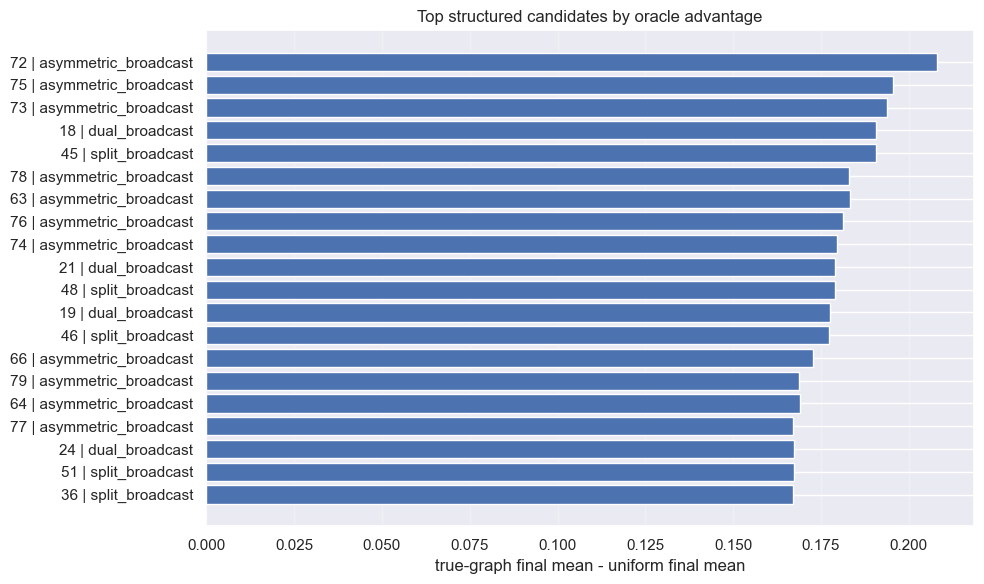

In [7]:
eligible_screen_df = screen_df[
    (screen_df["both_hubs_top_2"])
    & (screen_df["oracle_first_action_hub_fraction"] >= 0.50)
    & (screen_df["oracle_gap_final"] > 0.0)
].copy()

if len(eligible_screen_df) < TOP_K_CANDIDATES:
    raise RuntimeError(
        "Fewer than TOP_K_CANDIDATES passed the structural/oracle "
        "requirements. Inspect the screen instead of relaxing the "
        "requirements automatically."
    )

TOP_CANDIDATE_IDS = (
    eligible_screen_df
    .head(TOP_K_CANDIDATES)["candidate_id"]
    .astype(int)
    .tolist()
)

TOP_CANDIDATES = {
    int(candidate["candidate_id"]): candidate
    for candidate in CANDIDATES
    if int(candidate["candidate_id"]) in TOP_CANDIDATE_IDS
}

print("Frozen Stage-B candidate IDs:", TOP_CANDIDATE_IDS)
display(
    eligible_screen_df.head(TOP_K_CANDIDATES).round(5)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_plot = screen_df.head(20).iloc[::-1]
ax.barh(
    [
        f"{int(row.candidate_id)} | {row.family}"
        for row in top_plot.itertuples()
    ],
    top_plot["oracle_gap_final"],
)
ax.set_xlabel("true-graph final mean - uniform final mean")
ax.set_title("Top structured candidates by oracle advantage")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(
    RESULTS_DIR / "oracle_screen_top20.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

## Stage B — actual online nonlinear identifier

Only the already-frozen top candidates are evaluated here.

Each candidate is run with five independent identifier/RNG seeds.  A persistent
cache stores the full states, actions, and intermediate states for every learned
run.  Re-running the notebook therefore does not retrain completed cases.

In [8]:
def set_global_seed(seed: int) -> None:
    random.seed(int(seed))
    np.random.seed(int(seed))
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))


def sha256_json(payload: dict[str, Any]) -> str:
    return hashlib.sha256(
        json.dumps(
            payload,
            sort_keys=True,
            default=str,
        ).encode("utf-8")
    ).hexdigest()


def source_hash(obj: Any) -> str:
    path_string = inspect.getsourcefile(obj)
    if not path_string:
        return "unavailable"
    path = Path(path_string)
    if not path.exists():
        return "missing"
    return hashlib.sha256(path.read_bytes()).hexdigest()


SOURCE_HASHES = {
    "online_single_shot": source_hash(online_single_shot_module),
    "NetworkGraph": source_hash(NetworkGraph),
}


def learned_cache_dir(
    candidate_id: int,
    validation_seed: int,
) -> Path:
    candidate = TOP_CANDIDATES[int(candidate_id)]
    payload = {
        "pipeline_version": PIPELINE_VERSION,
        "study_name": STUDY_NAME,
        "candidate_id": int(candidate_id),
        "family": candidate["family"],
        "hub_influence_total": candidate["hub_influence_total"],
        "hub_level": candidate["hub_level"],
        "leaf_level": candidate["leaf_level"],
        "validation_seed": int(validation_seed),
        "model_kwargs": MODEL_KWARGS,
        "B_campaign": B_CAMPAIGN,
        "num_campaigns": NUM_CAMPAIGNS,
        "lambda_mix": LAMBDA_MIX,
        "identifier_kwargs": IDENTIFIER_KWARGS,
        "source_hashes": SOURCE_HASHES,
    }
    key = sha256_json(payload)
    return (
        CACHE_ROOT
        / f"candidate_{candidate_id:03d}"
        / f"seed_{validation_seed:02d}_{key[:16]}"
    )


def learned_cache_complete(
    candidate_id: int,
    validation_seed: int,
) -> bool:
    directory = learned_cache_dir(
        candidate_id,
        validation_seed,
    )
    return (
        (directory / "manifest.json").exists()
        and (directory / "rollout.npz").exists()
        and (directory / "summary.json").exists()
    )


def run_learned(
    candidate: dict[str, Any],
    validation_seed: int,
) -> dict[str, Any]:
    train_seed = (
        700_000
        + 1000 * int(candidate["candidate_id"])
        + int(validation_seed)
    )
    rng_seed = (
        800_000
        + 1000 * int(candidate["candidate_id"])
        + int(validation_seed)
    )
    set_global_seed(train_seed)

    env_template = make_env(
        candidate,
        seed=900_000 + int(candidate["candidate_id"]),
    )

    result = run_single_shot_online_identification(
        env_template,
        x0=np.asarray(candidate["x0"], dtype=float),
        random_initial_opinions=False,
        num_campaigns_total=NUM_CAMPAIGNS,
        t_campaign=T_CAMPAIGN,
        t_s=T_S,
        B_campaign=B_CAMPAIGN,
        lambda_mix=LAMBDA_MIX,
        exploration_campaigns=0,
        epsilon_schedule=EPSILON_SCHEDULE,
        lr=FIT_LR,
        l2_lambda=0.0,
        fit_max_steps=FIT_MAX_STEPS,
        fit_mae_stop=FIT_MAE_STOP,
        fit_batch_size=FIT_BATCH_SIZE,
        fit_check_every=FIT_CHECK_EVERY,
        identifier_kwargs=IDENTIFIER_KWARGS,
        device=DEVICE,
        rng_seed=rng_seed,
        suppress_fit_logs=True,
    )

    return {
        **dict(result),
        "policy": "learned_nonlinear",
    }


def save_learned_cache(
    candidate: dict[str, Any],
    validation_seed: int,
    result: dict[str, Any],
    summary: dict[str, Any],
) -> None:
    directory = learned_cache_dir(
        candidate["candidate_id"],
        validation_seed,
    )
    directory.mkdir(parents=True, exist_ok=True)

    arrays = {
        "states": np.asarray(result["states"], dtype=float),
        "actions": np.asarray(result["actions"], dtype=float),
    }
    for campaign, inter in enumerate(
        result["intermediate_states_list"]
    ):
        arrays[f"intermediate_{campaign:02d}"] = np.asarray(
            inter,
            dtype=float,
        )

    tmp_npz = directory / "rollout.tmp"
    with tmp_npz.open("wb") as handle:
        np.savez_compressed(handle, **arrays)
    os.replace(tmp_npz, directory / "rollout.npz")

    (directory / "summary.json").write_text(
        json.dumps(summary, indent=2),
        encoding="utf-8",
    )

    manifest = {
        "status": "success",
        "candidate_id": int(candidate["candidate_id"]),
        "validation_seed": int(validation_seed),
        "pipeline_version": PIPELINE_VERSION,
        "git_commit": GIT_COMMIT,
        "source_hashes": SOURCE_HASHES,
        "completed_at_utc": datetime.now(
            timezone.utc
        ).isoformat(),
    }
    (directory / "manifest.json").write_text(
        json.dumps(manifest, indent=2),
        encoding="utf-8",
    )


def load_learned_cache(
    candidate_id: int,
    validation_seed: int,
) -> tuple[dict[str, Any], dict[str, Any]]:
    directory = learned_cache_dir(
        candidate_id,
        validation_seed,
    )
    if not learned_cache_complete(candidate_id, validation_seed):
        raise FileNotFoundError(directory)

    summary = json.loads(
        (directory / "summary.json").read_text(
            encoding="utf-8"
        )
    )
    arrays = np.load(
        directory / "rollout.npz",
        allow_pickle=False,
    )
    inter_keys = sorted(
        key
        for key in arrays.files
        if key.startswith("intermediate_")
    )
    rollout = {
        "policy": "learned_nonlinear",
        "states": arrays["states"],
        "actions": arrays["actions"],
        "intermediate_states_list": [
            arrays[key]
            for key in inter_keys
        ],
    }
    return summary, rollout


VALIDATION_JOBS = [
    {
        "candidate_id": candidate_id,
        "validation_seed": validation_seed,
    }
    for candidate_id in TOP_CANDIDATE_IDS
    for validation_seed in LEARNED_VALIDATION_SEEDS
]

print("Stage-B learned jobs:", len(VALIDATION_JOBS))

Stage-B learned jobs: 15


In [9]:
def execute_validation_job(job: dict[str, int]) -> dict[str, Any]:
    candidate_id = int(job["candidate_id"])
    validation_seed = int(job["validation_seed"])
    candidate = TOP_CANDIDATES[candidate_id]

    if learned_cache_complete(candidate_id, validation_seed):
        summary, _ = load_learned_cache(
            candidate_id,
            validation_seed,
        )
        print(
            f"cache hit: candidate={candidate_id}, "
            f"seed={validation_seed}"
        )
        return summary

    print(
        f"running: candidate={candidate_id}, "
        f"seed={validation_seed}"
    )

    result = run_learned(candidate, validation_seed)
    learned_metrics = {
        **base_metrics(result),
        **model_mechanism_metrics(result, candidate),
    }

    uniform = rollout_fixed(candidate, policy="uniform")
    oracle = rollout_fixed(candidate, policy="true_graph")

    uniform_metrics = base_metrics(uniform)
    oracle_metrics = base_metrics(oracle)

    summary = {
        "candidate_id": candidate_id,
        "validation_seed": validation_seed,
        "family": candidate["family"],
        "hub_influence_total": candidate["hub_influence_total"],
        "hub_level": candidate["hub_level"],
        "leaf_level": candidate["leaf_level"],
        **{
            f"learned__{key}": value
            for key, value in learned_metrics.items()
        },
        "uniform__final_mean": uniform_metrics["final_mean"],
        "uniform__mean_over_campaigns": (
            uniform_metrics["mean_over_campaigns"]
        ),
        "oracle__final_mean": oracle_metrics["final_mean"],
        "oracle__mean_over_campaigns": (
            oracle_metrics["mean_over_campaigns"]
        ),
        "learned_gap_final": (
            learned_metrics["final_mean"]
            - uniform_metrics["final_mean"]
        ),
        "learned_gap_path": (
            learned_metrics["mean_over_campaigns"]
            - uniform_metrics["mean_over_campaigns"]
        ),
    }

    save_learned_cache(
        candidate,
        validation_seed,
        result,
        summary,
    )
    return summary


if WORKER_MODE:
    assigned_jobs = [
        job
        for index, job in enumerate(VALIDATION_JOBS)
        if index % NUM_SHARDS == SHARD_ID
    ]

    print("Assigned Stage-B jobs:", assigned_jobs)
    shard_rows = []

    for job in assigned_jobs:
        shard_rows.append(execute_validation_job(job))

    pd.DataFrame(shard_rows).to_csv(
        RESULTS_DIR / f"validation_shard_{SHARD_ID}.csv",
        index=False,
    )

    (
        RESULTS_DIR / f"SHARD_{SHARD_ID}_COMPLETE.json"
    ).write_text(
        json.dumps(
            {
                "status": "success",
                "shard_id": SHARD_ID,
                "jobs": assigned_jobs,
            },
            indent=2,
        ),
        encoding="utf-8",
    )

    print("Worker shard complete.")
else:
    missing_jobs = [
        job
        for job in VALIDATION_JOBS
        if not learned_cache_complete(
            job["candidate_id"],
            job["validation_seed"],
        )
    ]

    if missing_jobs:
        print(
            "Stage-B cache is incomplete. Either execute jobs directly "
            "by setting RUN_VALIDATION_IN_ANALYSIS=True below, or run "
            "three worker processes with the shard environment variable."
        )
        print("Missing jobs:", missing_jobs)

### Optional serial execution

Set `RUN_VALIDATION_IN_ANALYSIS = True` to run any missing Stage-B jobs in this
notebook.  Leave it false when using three worker processes.

In [10]:
RUN_VALIDATION_IN_ANALYSIS = False

if (
    not WORKER_MODE
    and RUN_VALIDATION_IN_ANALYSIS
):
    for job in VALIDATION_JOBS:
        execute_validation_job(job)

    print("Serial Stage-B validation complete.")

## Analyze the completed learned-validation stage

In [11]:
if not WORKER_MODE:
    missing_jobs = [
        job
        for job in VALIDATION_JOBS
        if not learned_cache_complete(
            job["candidate_id"],
            job["validation_seed"],
        )
    ]

    if not missing_jobs:
        validation_rows = []
        validation_rollouts = {}

        for job in VALIDATION_JOBS:
            summary, rollout = load_learned_cache(
                job["candidate_id"],
                job["validation_seed"],
            )
            validation_rows.append(summary)
            validation_rollouts[
                (
                    int(job["candidate_id"]),
                    int(job["validation_seed"]),
                )
            ] = rollout

        validation_df = pd.DataFrame(validation_rows)

        candidate_validation_df = (
            validation_df.groupby(
                [
                    "candidate_id",
                    "family",
                    "hub_influence_total",
                    "hub_level",
                    "leaf_level",
                ],
                as_index=False,
            )
            .agg(
                learned_gap_final_mean=(
                    "learned_gap_final",
                    "mean",
                ),
                learned_gap_final_std=(
                    "learned_gap_final",
                    "std",
                ),
                learned_gap_path_mean=(
                    "learned_gap_path",
                    "mean",
                ),
                learned_gap_path_std=(
                    "learned_gap_path",
                    "std",
                ),
                learned_final_mean=(
                    "learned__final_mean",
                    "mean",
                ),
                uniform_final_mean=(
                    "uniform__final_mean",
                    "mean",
                ),
                oracle_final_mean=(
                    "oracle__final_mean",
                    "mean",
                ),
            )
        )

        candidate_validation_df["learned_win_rate"] = [
            float(
                (
                    validation_df.loc[
                        validation_df["candidate_id"] == candidate_id,
                        "learned_gap_final",
                    ]
                    > 0
                ).mean()
            )
            for candidate_id in candidate_validation_df[
                "candidate_id"
            ]
        ]

        candidate_validation_df["learned_ci95_half"] = (
            1.96
            * candidate_validation_df["learned_gap_final_std"]
            / np.sqrt(len(LEARNED_VALIDATION_SEEDS))
        )

        candidate_validation_df = (
            candidate_validation_df.sort_values(
                [
                    "learned_gap_final_mean",
                    "learned_gap_path_mean",
                ],
                ascending=False,
            ).reset_index(drop=True)
        )

        validation_df.to_csv(
            RESULTS_DIR / "learned_validation_runs.csv",
            index=False,
        )
        candidate_validation_df.to_csv(
            RESULTS_DIR / "learned_validation_candidates.csv",
            index=False,
        )

        display(candidate_validation_df.round(5))

        BEST_CANDIDATE_ID = int(
            candidate_validation_df.iloc[0]["candidate_id"]
        )
        BEST_CANDIDATE = TOP_CANDIDATES[BEST_CANDIDATE_ID]

        print("Best validated candidate:", BEST_CANDIDATE_ID)
    else:
        print(
            "Analysis deferred until all Stage-B learned jobs are cached."
        )

,candidate_id,family,hub_influence_total,hub_level,leaf_level,learned_gap_final_mean,learned_gap_final_std,learned_gap_path_mean,learned_gap_path_std,learned_final_mean,uniform_final_mean,oracle_final_mean,learned_win_rate,learned_ci95_half
0,72,asymmetric_broadcast,0.85,0.16,0.48,0.11004,0.05562,0.09148,0.03566,0.52442,0.41438,0.62253,1.0,0.04875
1,75,asymmetric_broadcast,0.85,0.24,0.48,0.10331,0.05236,0.08478,0.03474,0.55238,0.44907,0.64464,1.0,0.04590
2,73,asymmetric_broadcast,0.85,0.16,0.58,0.10207,0.05236,0.08427,0.03514,0.55817,0.45610,0.64994,1.0,0.04589


Best validated candidate: 72


## Individual-node trajectories for the best validated candidate

Representative validation seed: 4


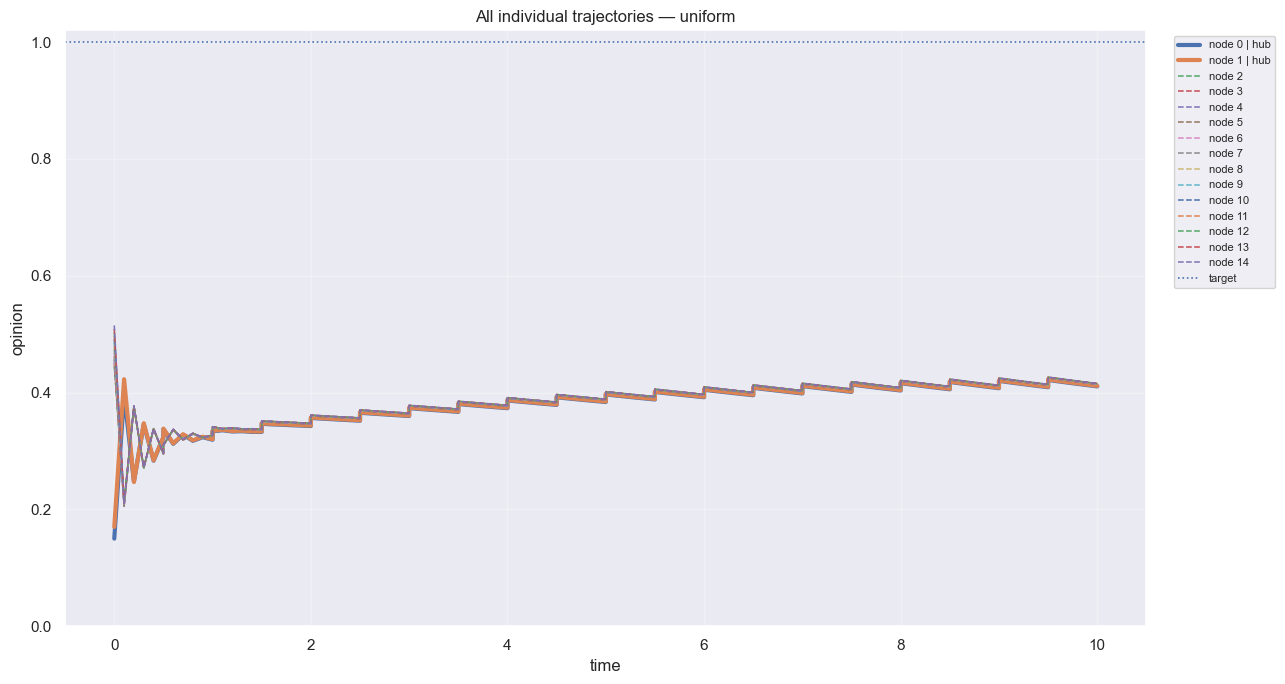

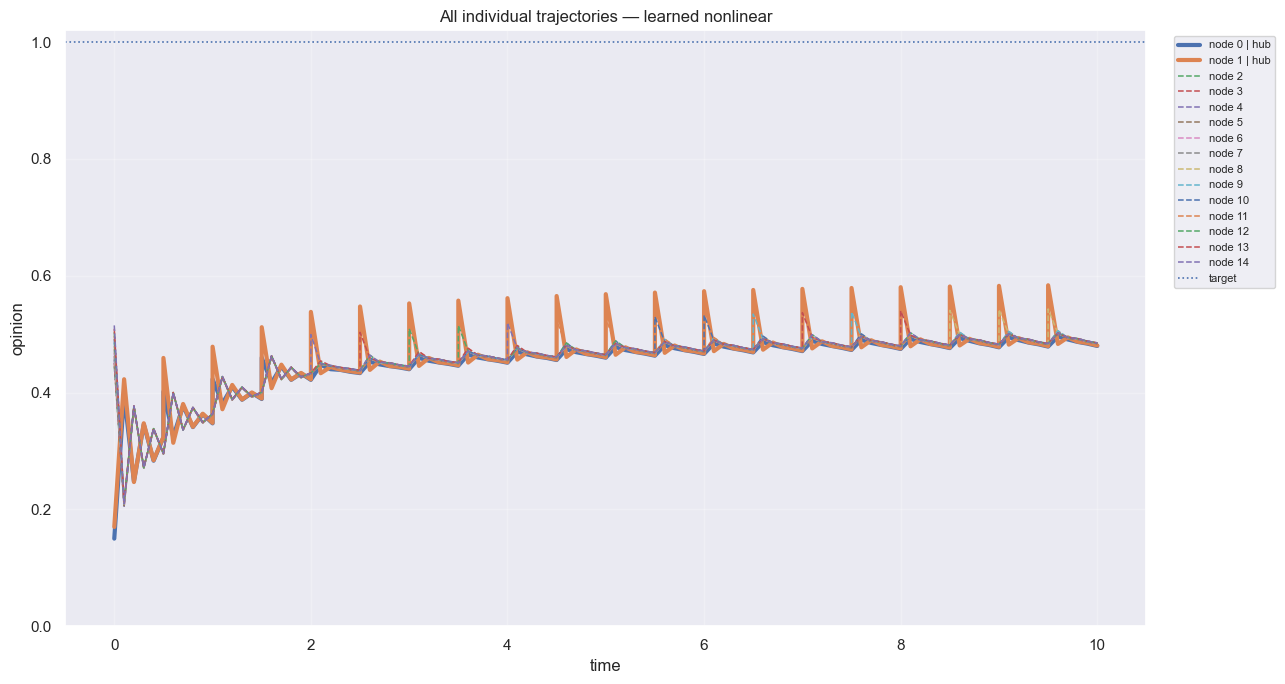

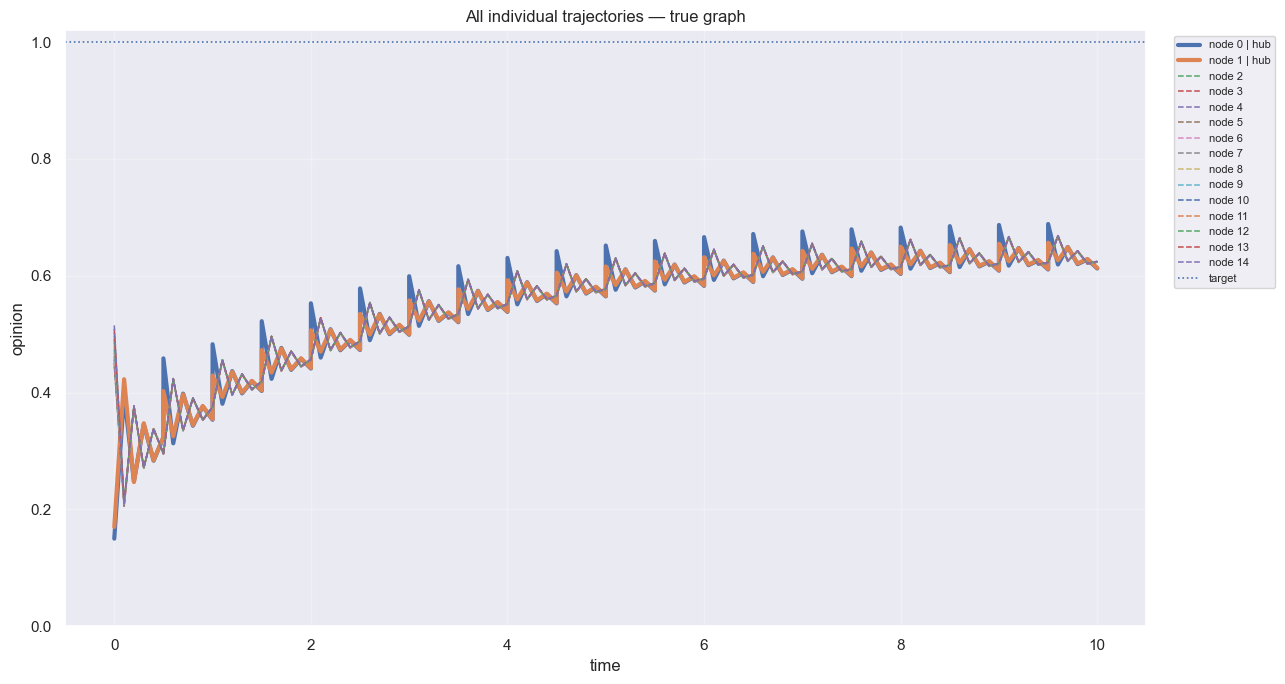

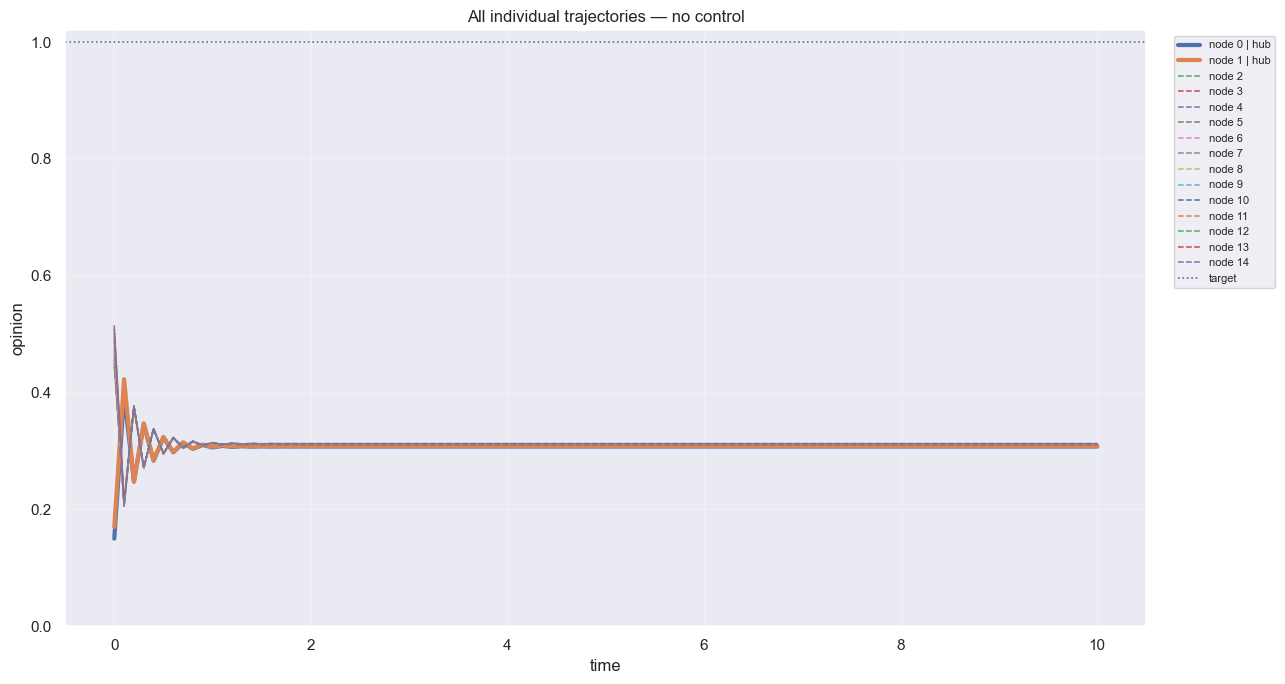

In [12]:
def fine_trajectory(
    rollout: dict[str, Any],
) -> tuple[np.ndarray, np.ndarray]:
    states = [np.asarray(rollout["states"][0], dtype=float)]
    times = [0.0]

    for campaign, inter in enumerate(
        rollout["intermediate_states_list"]
    ):
        inter = np.asarray(inter, dtype=float)
        t0 = campaign * T_CAMPAIGN

        times.append(t0)
        states.append(inter[0])

        for step in range(1, len(inter)):
            times.append(t0 + step * T_S)
            states.append(inter[step])

    return np.asarray(times), np.asarray(states)


def plot_all_nodes(
    rollout: dict[str, Any],
    *,
    title: str,
    filename: str,
) -> None:
    times, states = fine_trajectory(rollout)

    fig, ax = plt.subplots(figsize=(13, 7))

    for node in range(N):
        is_hub = node in HUBS
        ax.plot(
            times,
            states[:, node],
            linewidth=3.0 if is_hub else 1.1,
            linestyle="-" if node in HUBS else "--",
            label=(
                f"node {node}"
                + (" | hub" if is_hub else "")
            ),
        )

    ax.axhline(
        TARGET,
        linestyle=":",
        linewidth=1.2,
        label="target",
    )
    ax.set_xlabel("time")
    ax.set_ylabel("opinion")
    ax.set_ylim(0.0, 1.02)
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend(
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        fontsize=8,
    )
    fig.tight_layout()
    fig.savefig(
        RESULTS_DIR / filename,
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)


if (
    not WORKER_MODE
    and "candidate_validation_df" in globals()
):
    best_rows = validation_df[
        validation_df["candidate_id"] == BEST_CANDIDATE_ID
    ].sort_values("learned_gap_final")

    # Median learned run is more representative than cherry-picking the best seed.
    median_row = best_rows.iloc[len(best_rows) // 2]
    representative_seed = int(
        median_row["validation_seed"]
    )

    learned_rollout = validation_rollouts[
        (BEST_CANDIDATE_ID, representative_seed)
    ]
    uniform_rollout = rollout_fixed(
        BEST_CANDIDATE,
        policy="uniform",
    )
    oracle_rollout = rollout_fixed(
        BEST_CANDIDATE,
        policy="true_graph",
    )
    no_control_rollout = rollout_fixed(
        BEST_CANDIDATE,
        policy="no_control",
    )

    print(
        "Representative validation seed:",
        representative_seed,
    )

    plot_all_nodes(
        uniform_rollout,
        title="All individual trajectories — uniform",
        filename="best_candidate_all_nodes_uniform.png",
    )
    plot_all_nodes(
        learned_rollout,
        title="All individual trajectories — learned nonlinear",
        filename="best_candidate_all_nodes_learned.png",
    )
    plot_all_nodes(
        oracle_rollout,
        title="All individual trajectories — true graph",
        filename="best_candidate_all_nodes_oracle.png",
    )
    plot_all_nodes(
        no_control_rollout,
        title="All individual trajectories — no control",
        filename="best_candidate_all_nodes_no_control.png",
    )

## Learned allocation and topology diagnostics

,node,is_hub,x0,true_centrality,column_sum_outgoing_influence
0,0,True,0.15000,0.34343,8.48750
1,1,True,0.17000,0.17172,2.96250
5,5,False,0.46250,0.05386,0.28333
4,4,False,0.45667,0.05386,0.28333
3,3,False,0.45083,0.05371,0.28333
6,6,False,0.46833,0.05371,0.28333
7,7,False,0.47417,0.05171,0.28333
2,2,False,0.44500,0.05171,0.28333
8,8,False,0.48000,0.02525,0.26429
14,14,False,0.51500,0.02525,0.26429


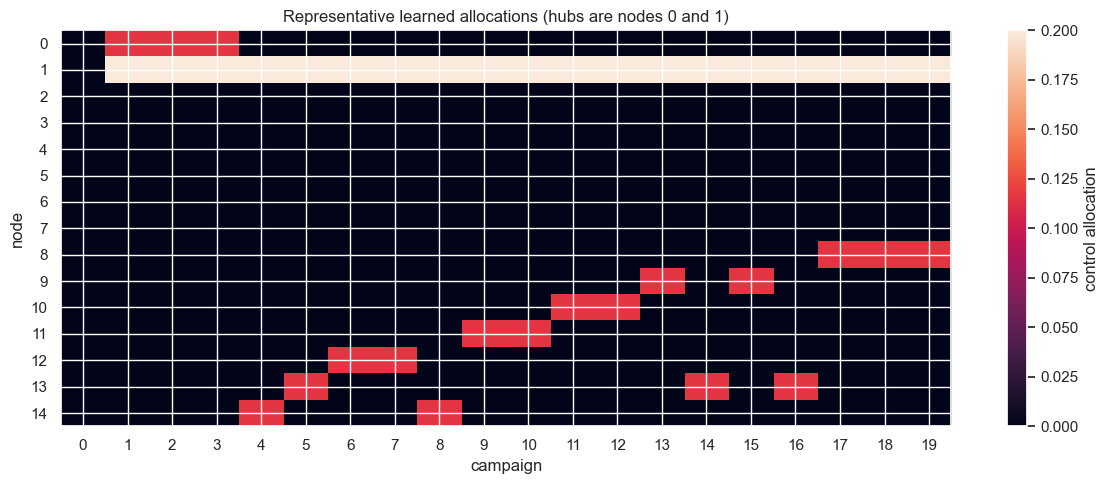

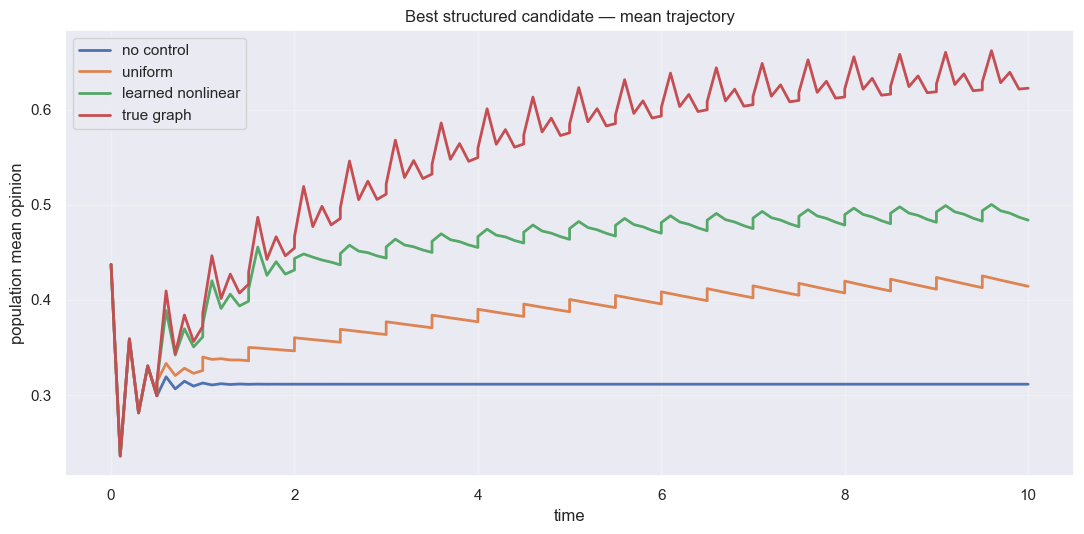

In [13]:
if (
    not WORKER_MODE
    and "candidate_validation_df" in globals()
):
    A = np.asarray(BEST_CANDIDATE["A"], dtype=float)
    v = np.asarray(BEST_CANDIDATE["v_true"], dtype=float)

    topology_table = pd.DataFrame(
        {
            "node": np.arange(N),
            "is_hub": [
                node in HUBS for node in range(N)
            ],
            "x0": BEST_CANDIDATE["x0"],
            "true_centrality": v,
            "column_sum_outgoing_influence": A.sum(axis=0),
        }
    ).sort_values(
        "true_centrality",
        ascending=False,
    )
    display(topology_table.round(5))

    actions = np.asarray(
        learned_rollout["actions"],
        dtype=float,
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    image = ax.imshow(
        actions.T,
        aspect="auto",
        interpolation="nearest",
    )
    ax.set_xlabel("campaign")
    ax.set_ylabel("node")
    ax.set_title(
        "Representative learned allocations "
        "(hubs are nodes 0 and 1)"
    )
    ax.set_xticks(np.arange(actions.shape[0]))
    ax.set_yticks(np.arange(N))
    fig.colorbar(
        image,
        ax=ax,
        label="control allocation",
    )
    fig.tight_layout()
    fig.savefig(
        RESULTS_DIR / "best_candidate_learned_actions.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    # Direct policy mean comparison.
    fig, ax = plt.subplots(figsize=(11, 5.5))
    for rollout, label in [
        (no_control_rollout, "no control"),
        (uniform_rollout, "uniform"),
        (learned_rollout, "learned nonlinear"),
        (oracle_rollout, "true graph"),
    ]:
        times, states = fine_trajectory(rollout)
        ax.plot(
            times,
            states.mean(axis=1),
            linewidth=2.0,
            label=label,
        )

    ax.set_xlabel("time")
    ax.set_ylabel("population mean opinion")
    ax.set_title("Best structured candidate — mean trajectory")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    fig.savefig(
        RESULTS_DIR / "best_candidate_mean_comparison.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

## How to use the result

The topology is selected **only** from Stage A's oracle-vs-uniform screen.

Stage B then answers a separate question: can the current learned online
controller recover the available advantage?

A useful final structured benchmark should satisfy all of the following:

1. true-graph control has a clear advantage over uniform;
2. that advantage follows the intended mechanism rather than an accidental
   numerical artifact;
3. the learned controller wins consistently across repeated training seeds;
4. the learned policy's individual trajectories and allocations visibly agree
   with the mechanism;
5. after choosing the topology, a separate robustness notebook should perturb
   edge weights and initial opinions without re-selecting the topology.

This prevents the learned-controller test from becoming a direct search for a
favorable seed.